In [1]:
# Data Manipulation
import pandas as pd
import numpy as np
import requests
from io import StringIO

# Visualization (Static)
import matplotlib.pyplot as plt
import seaborn as sns

# Visualization (Interactive)
import plotly.express as px

# Machine Learning & Clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LassoCV
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
# Packages for visualizing the tree
from sklearn.metrics import accuracy_score, f1_score, brier_score_loss
from sklearn.tree import export_graphviz
from sklearn.tree import export_text
# Code for the bootstrap resample
from sklearn.utils import resample
from sklearn.tree import plot_tree

# Import Data 

In [2]:
 # 1) All variables and countries from the master data
master_data = (pd.read_csv("https://raw.githubusercontent.com/AyaanTigdikar/Capstone/refs/heads/main/MASTER/Master.csv")
               .drop(columns=['Unnamed: 0'], errors='ignore'))

# Countries high in natural resources & not developed
master_data = master_data[master_data['Country Code'].isin(['AGO', 'ARE', 'AZE', 'BFA', 'BHR', 'BOL', 'CHL', 'CIV', 'CMR',
       'COD', 'COG', 'DZA', 'ECU', 'EGY', 'ETH', 'GAB', 'GHA', 'GIN',
       'GNQ', 'IDN', 'IRN', 'IRQ', 'KAZ', 'KEN', 'KWT', 'LAO', 'LBR',
       'LBY', 'MDG', 'MLI', 'MMR', 'MNG', 'MOZ', 'MWI', 'MYS', 'NER',
       'NGA', 'OMN', 'PNG', 'QAT', 'RUS', 'RWA', 'SAU', 'TCD', 'TGO',
       'TTO', 'TZA', 'UGA', 'UZB', 'VEN', 'VNM', 'YEM', 'ZMB', 'ZWE'])]

# 2) Clusters list from Leo
clusters_list = pd.read_csv('https://raw.githubusercontent.com/AyaanTigdikar/Capstone/refs/heads/main/workingdata/clusters_list.csv')


#master_data = master_data.merge(clusters_list, on = ['Country Code', 'Country Name'], how='left')

In [3]:
# Note: I am replacing the previous master data long with Ayaan's master data
master_data_long = master_data.melt(
    id_vars=['Country Code', 'Country Name', 'Year'],
    var_name= 'Variable',
    value_name='Value'
)

master_data_long

,Country Code,Country Name,Year,Variable,Value
0,AGO,Angola,1995,Access to electricity (% of population),24.2
1,AGO,Angola,1996,Access to electricity (% of population),24.2
2,AGO,Angola,1997,Access to electricity (% of population),24.2
3,AGO,Angola,1998,Access to electricity (% of population),24.2
4,AGO,Angola,1999,Access to electricity (% of population),24.2
...,...,...,...,...,...
59395,ZWE,Zimbabwe,2015,Population,14399013.0
59396,ZWE,Zimbabwe,2016,Population,14600294.0
59397,ZWE,Zimbabwe,2017,Population,14812482.0
59398,ZWE,Zimbabwe,2018,Population,15034452.0


## 1) Collapsed data (1 row per country)

### Pre-processing 

In [4]:
windows = {
    3: ([1995, 1996, 1997], [2017, 2018, 2019]),
    5: ([1995, 1996, 1997, 1998, 1999], [2015, 2016, 2017, 2018, 2019]),
    7: ([1995, 1996, 1997, 1998, 1999, 2000, 2001], 
        [2013, 2014, 2015, 2016, 2017, 2018, 2019])
}

results = {}

for k, (start_years, end_years) in windows.items():

    df_k = master_data_long[
        master_data_long['Year'].isin(start_years + end_years)
    ].copy()

    pivot = df_k.pivot_table(
        index=['Country Code', 'Variable'],
        columns='Year',
        values='Value'
    )

    # Averages
    pivot['avg_start'] = pivot[start_years].mean(axis=1)
    pivot['avg_end']   = pivot[end_years].mean(axis=1)

    # Build variable-specific outcome
    pivot['value_out'] = pivot['avg_start']              # Average start years for all variables except ECI
    pivot.loc[
        pivot.index.get_level_values('Variable') == 'Economic Complexity Index', # For values assigned with ECI, replace value_out with net change 
        'value_out'
    ] = pivot['avg_end'] - pivot['avg_start']             # ECI net change

    # To wide
    df_out = pivot['value_out'].reset_index().pivot(
        index='Country Code',
        columns='Variable',
        values='value_out'
    )

    results[k] = df_out.merge(
        clusters_list,
        how='right',
        on='Country Code'
    )

# Final outputs
df_3_change_clusters = results[3]
df_5_change_clusters = results[5]
df_7_change_clusters = results[7]


#### NA check

In [5]:
df_3_change_clusters.isna().sum()

Country Code                                                            0
Access to electricity (% of population)                                88
Adjusted savings: gross savings (% of GNI)                             88
Agriculture                                                            88
Capital depreciation rate                                              88
Clientelism index                                                      88
Death rates, crude per 1000 people                                     88
Domestic credit to private sector (% of GDP)                           88
Economic Complexity Index                                              88
GDP per capita (constant prices, PPP)                                  88
Government revenue                                                     88
Gross fixed capital formation, all, Constant prices, Percent of GDP    88
Human capital index                                                    88
Hydrocarbons_Dominant                 

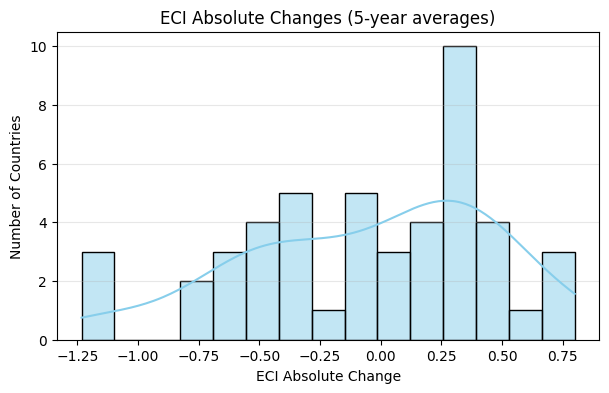

In [6]:
# Histogram of ECI changes
dfs = {
#    3: df_3_change_clusters,
     5: df_5_change_clusters,
#    7: df_7_change_clusters
}

for k, df in dfs.items():
    plt.figure(figsize=(7,4))
    sns.histplot(df['Economic Complexity Index'], bins=15, kde=True, color='skyblue')
    plt.title(f'ECI Absolute Changes ({k}-year averages)')
    plt.xlabel('ECI Absolute Change')
    plt.ylabel('Number of Countries')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and pos

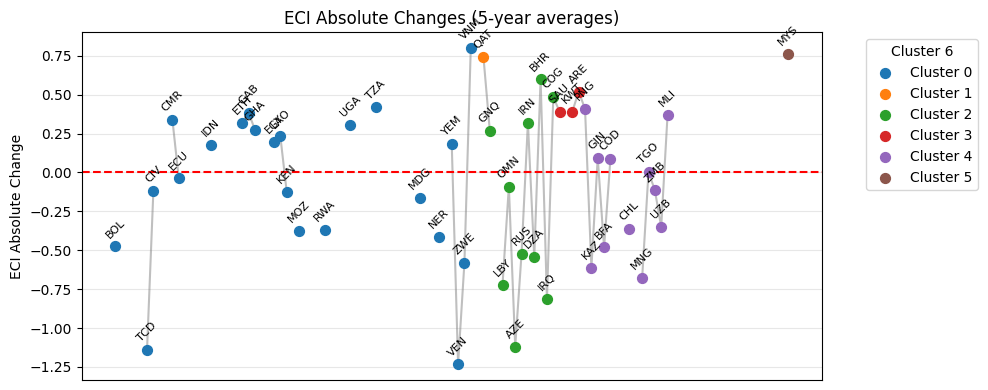

In [7]:
dfs = {
#    3: df_3_change_clusters,
     5: df_5_change_clusters,
#    7: df_7_change_clusters
}

for k, df in dfs.items():

    df_sorted = df.sort_values('cluster_6').reset_index(drop=True)

    plt.figure(figsize=(10,4))

    unique_clusters = df_sorted['cluster_6'].unique()
    palette = sns.color_palette("tab10", n_colors=len(unique_clusters))
    cluster_colors = dict(zip(unique_clusters, palette))

    # Line
    plt.plot(df_sorted.index, df_sorted['Economic Complexity Index'],
             linestyle='-', color='gray', alpha=0.5)

    # Points + labels
    for cluster in unique_clusters:
        cluster_data = df_sorted[df_sorted['cluster_6'] == cluster]
        plt.scatter(cluster_data.index,
                    cluster_data['Economic Complexity Index'],
                    color=cluster_colors[cluster],
                    s=50,
                    label=f'Cluster {cluster}',
                    zorder=3)

        for i, row in cluster_data.iterrows():
            plt.text(i,
                     row['Economic Complexity Index'] + 0.04,
                     row['Country Code'],
                     ha='center',
                     va='bottom',
                     fontsize=8,
                     rotation=45)

    plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
    plt.xticks([])
    plt.title(f'ECI Absolute Changes ({k}-year averages)')
    plt.ylabel('ECI Absolute Change')
    plt.grid(alpha=0.3)
    plt.legend(title='Cluster 6', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


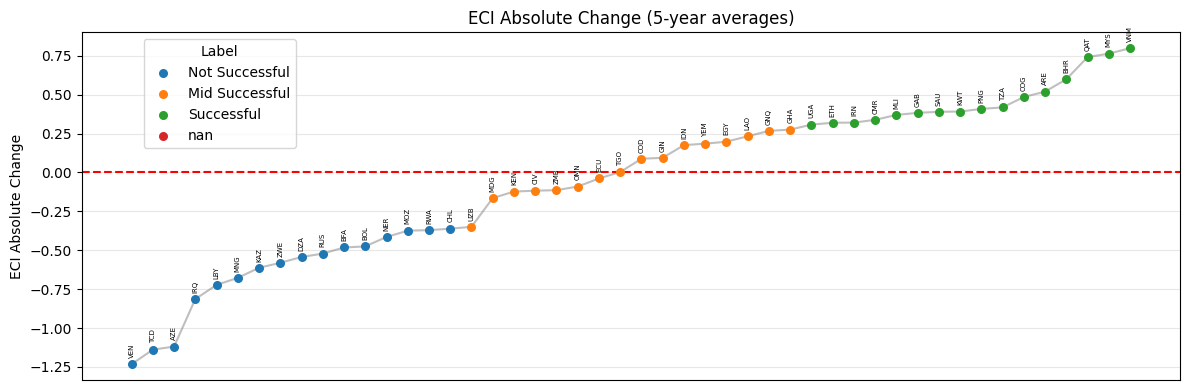

In [8]:
dfs = {
#    3: df_3_change_clusters,
    5: df_5_change_clusters,
#    7: df_7_change_clusters
}

for k, df in dfs.items():
    # Create a categorical variable with 3 equally sized groups
    df_5_change_clusters['label'] = pd.qcut(
        df_5_change_clusters['Economic Complexity Index'], 
        q=3,  # split into 3 quantiles
        labels=['Not Successful', 'Mid Successful', 'Successful']
        )

    # Sort by ECI change
    df_sorted = df_5_change_clusters.sort_values('Economic Complexity Index').reset_index(drop=True)

    plt.figure(figsize=(12,4))

    # Generate a color palette based on unique clusters
    unique_clusters = df_sorted['label'].unique()
    palette = sns.color_palette("tab10", n_colors=len(unique_clusters))
    cluster_colors = {cluster: color for cluster, color in zip(unique_clusters, palette)}

    # Plot line connecting points (gray)
    plt.plot(df_sorted.index, df_sorted['Economic Complexity Index'], linestyle='-', color='gray', alpha=0.5)

    # Plot points colored by cluster and keep references for legend
    scatter_handles = []
    for cluster in unique_clusters:
        cluster_data = df_sorted[df_sorted['label'] == cluster]
        sc = plt.scatter(cluster_data.index, cluster_data['Economic Complexity Index'],
                         color=cluster_colors[cluster], s=30, label=f'{cluster}', zorder=3)
        scatter_handles.append(sc)
        # Annotate each point with country code
        for i, row in cluster_data.iterrows():
            plt.text(i, row['Economic Complexity Index'] + 0.04, row['Country Code'], 
                    ha='center', va='bottom', fontsize=5, rotation=90)

    # Remove x-axis labels
    plt.xticks([])
    # Add red dashed horizontal line at 0
    plt.axhline(y=0.0, color='red', linestyle='--', linewidth=1.5)
    plt.title(f'ECI Absolute Change ({k}-year averages)')
    plt.xlabel('')
    plt.ylabel('ECI Absolute Change')
    plt.grid(alpha=0.3)
    plt.legend(title='Label', bbox_to_anchor=(.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

## LASSO

c:\Users\ayaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.068e-03, tolerance: 1.068e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\ayaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.607e-03, tolerance: 1.068e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\ayaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

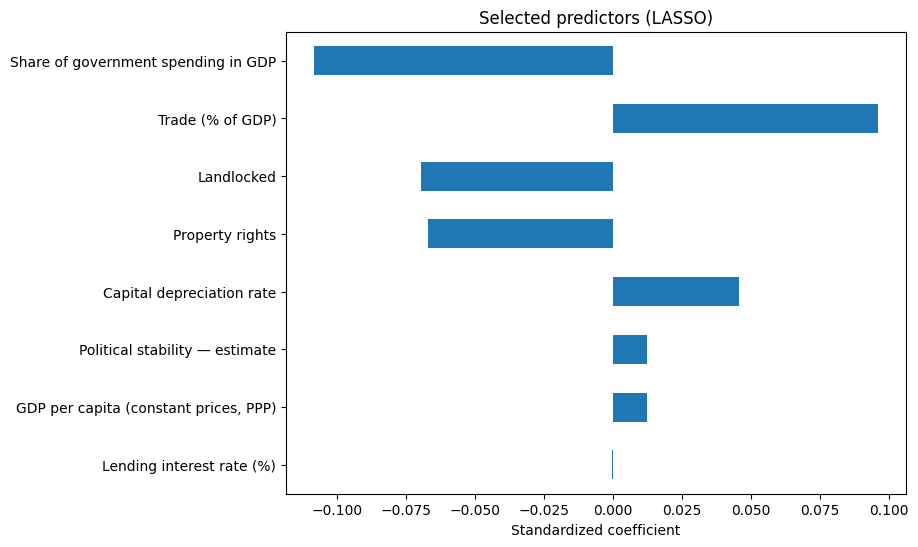

In [9]:
# ----------------------------
# 1. Drop rows with missing outcome
# ----------------------------
df_clean = df_5_change_clusters.dropna(subset=['Economic Complexity Index']).copy()
df_clean = df_clean.dropna(axis=1, how='all')

# ----------------------------
# 2. Separate outcome and predictors
# ----------------------------
y = df_clean['Economic Complexity Index'].values

X = df_clean.drop(columns=['Country Code', 'Country Name', 'cluster_6', 'Economic Complexity Index', 'label']).values
feature_names = df_clean.drop(columns=['Country Code', 'Country Name', 'cluster_6', 'Economic Complexity Index', 'label']).columns

# ----------------------------
# 3. Impute missing predictor values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ----------------------------
# 4. Standardize predictors
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ----------------------------
# 5. LASSO with cross-validation
# ----------------------------
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients (indexed by feature names, not rows!)
# ----------------------------
coef = pd.Series(lasso_cv.coef_, index=feature_names)
#print("LASSO coefficients:\n", coef)

# ----------------------------
# 7. Selected predictors (non-zero coefficients)
# ----------------------------
selected = coef[coef != 0].sort_values(key=abs, ascending=False)
#print("Selected predictors:\n", selected)

# ----------------------------
# 8. Optional: Plot
# ----------------------------
plt.figure(figsize=(8,6))
selected.plot(kind='barh')
plt.title("Selected predictors (LASSO)")
plt.xlabel("Standardized coefficient")
plt.gca().invert_yaxis()
plt.show()


#### LASSO Robustness

In [10]:
# 1) Different subsamples
n_boot = 50
selected = pd.DataFrame(0, index=feature_names, columns=range(n_boot))

for b in range(n_boot):
    idx = np.random.choice(len(y), size=len(y), replace=True)
    
    X_b = X_scaled[idx]
    y_b = y[idx]

    lasso = LassoCV(cv=5, max_iter=10000, random_state=b)
    lasso.fit(X_b, y_b)

    selected.iloc[:, b] = (lasso.coef_ != 0).astype(int)

selection_freq = selected.mean(axis=1).sort_values(ascending=False)
print(selection_freq)

c:\Users\ayaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.649e-03, tolerance: 8.932e-04
  model = cd_fast.enet_coordinate_descent(
c:\Users\ayaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.888e-03, tolerance: 1.020e-03
  model = cd_fast.enet_coordinate_descent(
c:\Users\ayaan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the sca

Landlocked                                                             0.90
Trade (% of GDP)                                                       0.88
Capital depreciation rate                                              0.88
Property rights                                                        0.82
Share of government spending in GDP                                    0.74
Political stability — estimate                                         0.56
Clientelism index                                                      0.52
Adjusted savings: gross savings (% of GNI)                             0.52
Population                                                             0.46
Human capital index                                                    0.44
Services                                                               0.44
Real interest rate (%)                                                 0.42
Gross fixed capital formation, all, Constant prices, Percent of GDP    0.40
Lending inte

## Ridge

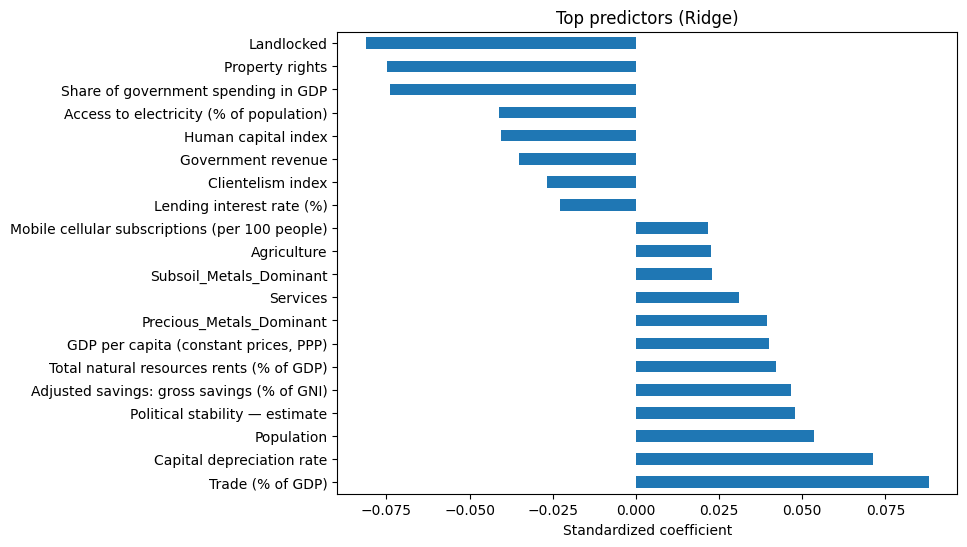

In [11]:
# ----------------------------
# 5. RIDGE with cross-validation
# ----------------------------
ridge_cv = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=10
)
ridge_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients
# ----------------------------
coef = pd.Series(ridge_cv.coef_, index=feature_names)

# ----------------------------
# 7. Rank predictors by importance
# ----------------------------
ranked = coef.abs().sort_values(ascending=False)

# ----------------------------
# 8. Optional: Plot top coefficients
# ----------------------------
top_k = 20  # change if needed

plt.figure(figsize=(8, 6))
coef.loc[ranked.index[:top_k]].sort_values().plot(kind='barh')
plt.title("Top predictors (Ridge)")
plt.xlabel("Standardized coefficient")
plt.gca().invert_yaxis()
plt.show()


## Single tree

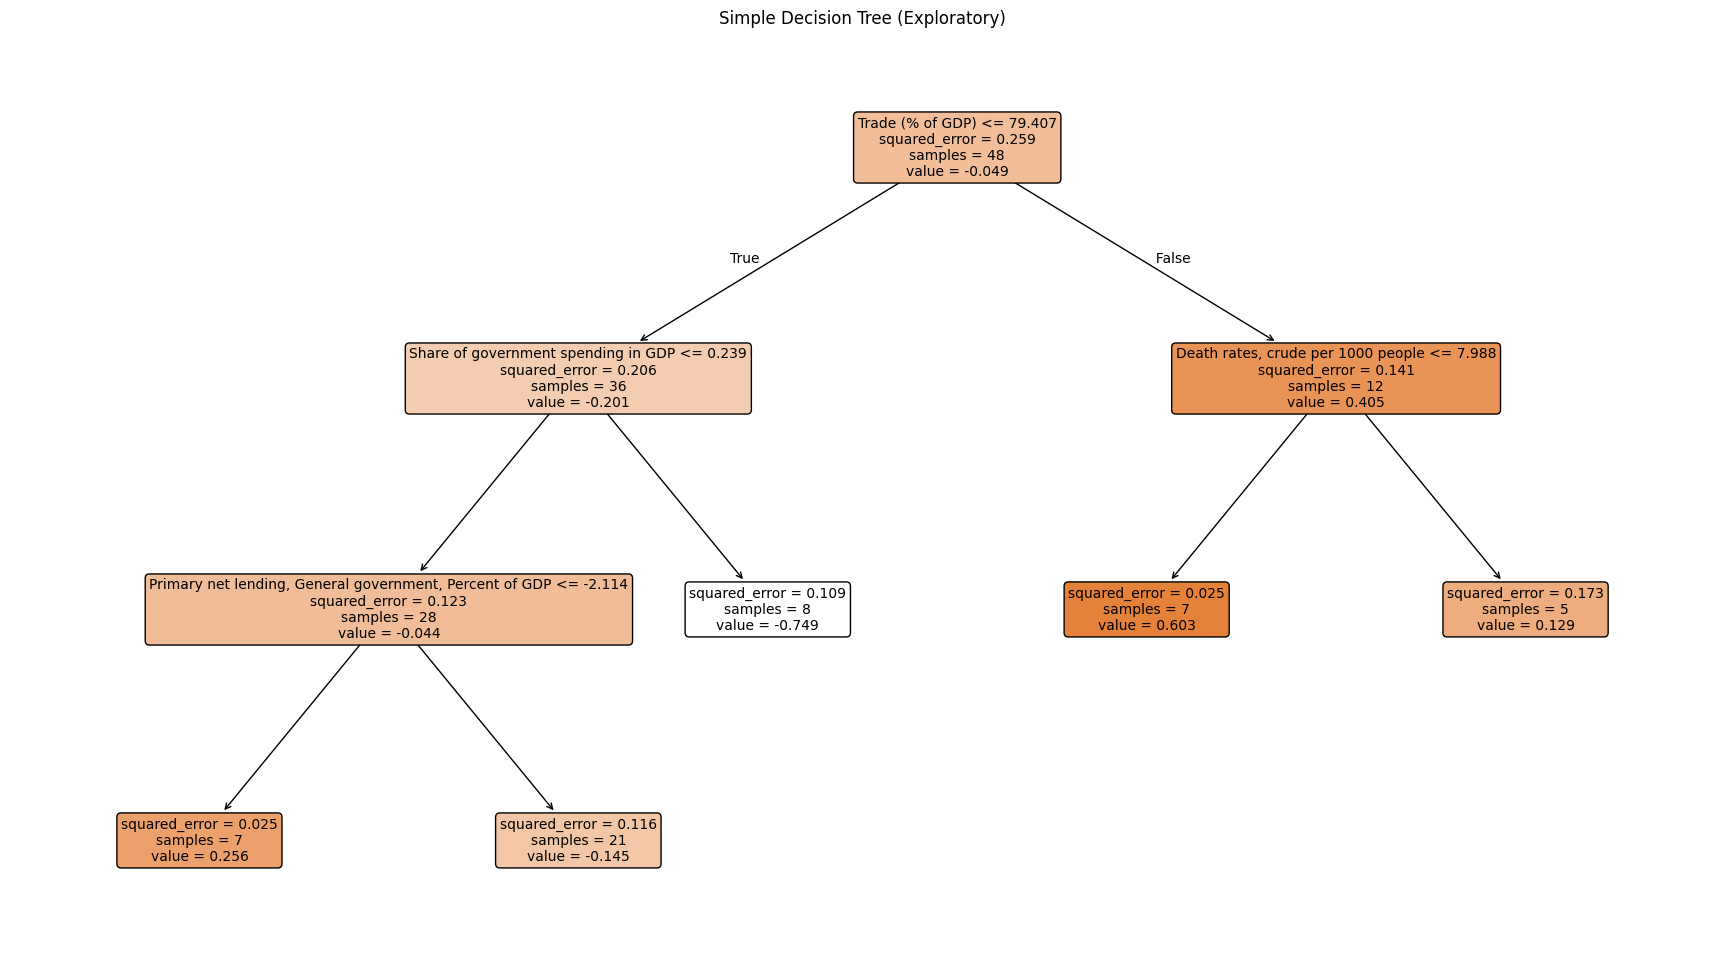

In [12]:
# ----------------------------
# 1. Drop rows with missing outcome
# ----------------------------
df_clean = df_5_change_clusters.dropna(
    subset=['Economic Complexity Index']
).copy() # Drops rows with missing ECI

df_clean = df_clean.dropna(axis=1, how='all') # Drops all missing columns (they don't have data for the start year)

# ----------------------------
# 2. Separate outcome and predictors
# ----------------------------
y = df_clean['Economic Complexity Index'].values

X_df = df_clean.drop(
    columns=['Country Code', 'Country Name', 'cluster_6',
             'Economic Complexity Index', 'label'],
    errors='ignore'
)

feature_names = X_df.columns
X = X_df.values

# ----------------------------
# 3. Impute missing predictor values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ----------------------------
# 4. Fit simple decision tree
# ----------------------------
tree_simple = DecisionTreeRegressor(
    max_depth=3,          # shallow & interpretable
    min_samples_leaf=5,
    random_state=42
)

tree_simple.fit(X_imputed, y)

# ----------------------------
# 5. Visualize simple tree
# ----------------------------
plt.figure(figsize=(22, 12))
plot_tree(
    tree_simple,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Simple Decision Tree (Exploratory)")
plt.show()


## Random Forest

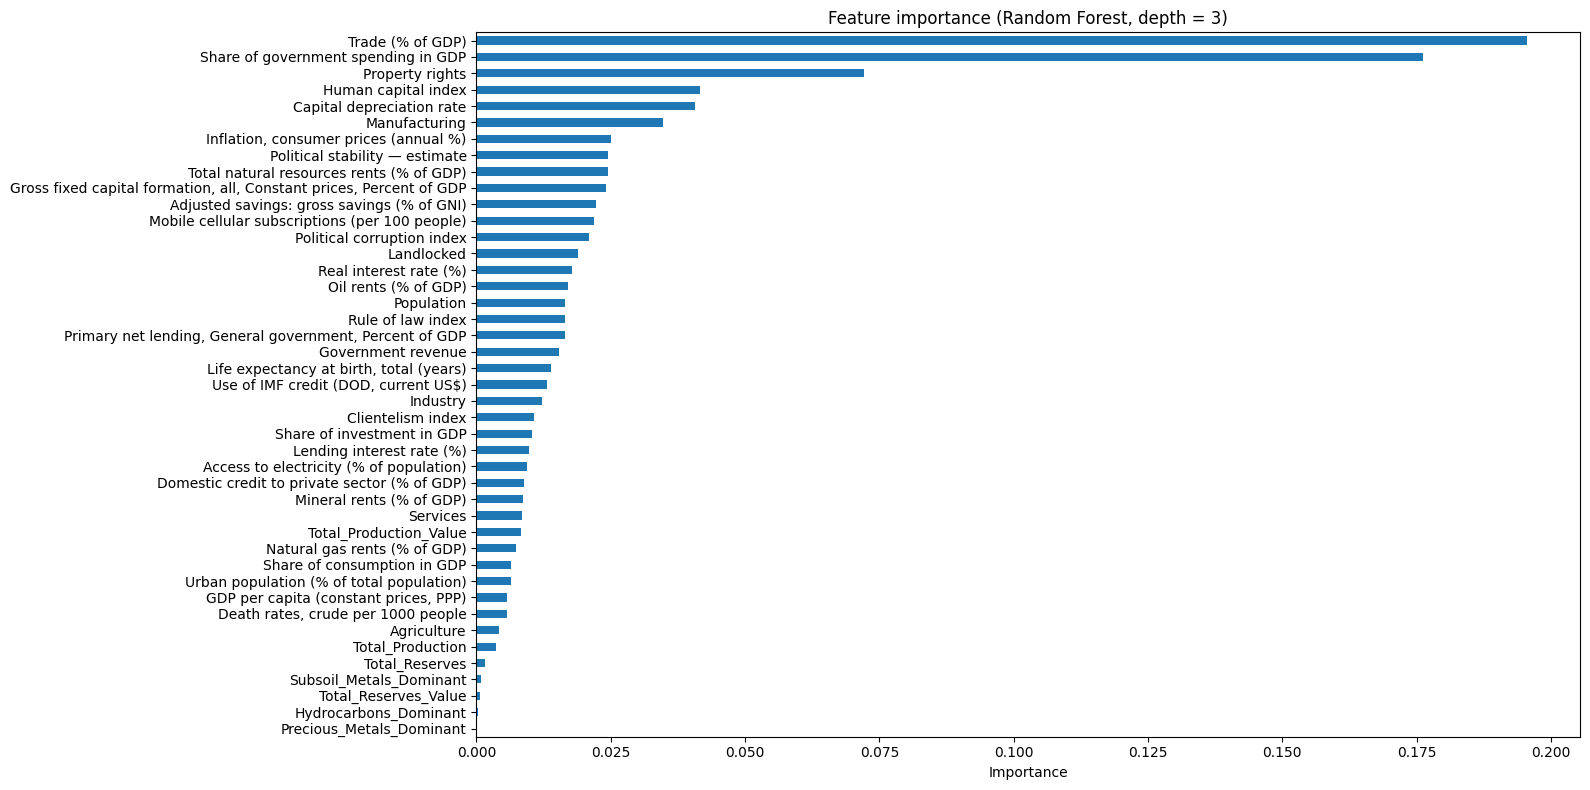

In [13]:
# ----------------------------
# 6. Random Forest (3 levels)
# ----------------------------
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=4,          # <-- 3 levels
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imputed, y)

# ----------------------------
# 7. Feature importance
# ----------------------------
importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

#print("Random Forest feature importance:\n", importance)

# ----------------------------
# 7. Plot importance
# ----------------------------
plt.figure(figsize=(16,8))
importance.plot(kind='barh')
plt.title("Feature importance (Random Forest, depth = 3)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#### Random Forest Robustness

In [14]:
# Out of bag (OOB): it's like R2 for RF
rf_oob = RandomForestRegressor(
    n_estimators=1000,
    max_depth=4,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)

rf_oob.fit(X_imputed, y)

print("OOB R²:", rf_oob.oob_score_)


OOB R²: 0.07552807609056111


## 2) Panel data (25 rows per country)

## Lag creation

In [15]:
## Lagged variables
master_data = master_data.sort_values(['Country Code', 'Country Name', 'Year'])

master_data_lags_ECI = master_data.copy()
master_data_lags = master_data.copy()
lag = 1

# 1) Data only with lagged ECI
master_data_lags_ECI['L1_Economic Complexity Index'] = master_data.groupby('Country Code')['Economic Complexity Index'].shift(lag)

# 2) Data with all lagged variables
vars_to_lag = [col for col in master_data.columns if col not in ['Country Code', 'Country Name',  'Year']]

for var in vars_to_lag:
    master_data_lags[f'L{lag}_{var}'] = master_data_lags.groupby('Country Code')[var].shift(lag)

vars_to_lag.remove('Economic Complexity Index') # Just to not remove ECI at levels (is our dependant variable)

master_data_lags = master_data_lags.drop(columns = vars_to_lag)

# Drop rows with NaNs created by lagging
master_data_lags_ECI = master_data_lags_ECI.dropna()
master_data_lags = master_data_lags.dropna()

master_data_lags_ECI

,Country Code,Country Name,Year,Access to electricity (% of population),Adjusted savings: gross savings (% of GNI),Agriculture,Capital depreciation rate,Clientelism index,"Death rates, crude per 1000 people",Domestic credit to private sector (% of GDP),...,"Use of IMF credit (DOD, current US$)",Total_Production,Total_Reserves,Total_Production_Value,Total_Reserves_Value,Hydrocarbons_Dominant,Subsoil_Metals_Dominant,Precious_Metals_Dominant,Population,L1_Economic Complexity Index
1,AGO,Angola,1996,24.2,48.055414,9.386791,0.038398,0.840,18.445,22.274928,...,0.0,2.613313e+08,1348675.0,5.894739e+09,3.042149e+07,1,0,0,14170973.0,-1.914
2,AGO,Angola,1997,24.2,48.055414,9.386791,0.040405,0.840,18.184,22.274928,...,0.0,2.704650e+08,1423500.0,5.405294e+09,2.844892e+07,1,0,0,14660413.0,-2.328
3,AGO,Angola,1998,24.2,48.055414,9.386791,0.040825,0.840,18.925,22.274928,...,0.0,2.667600e+08,1470950.0,3.392030e+09,1.870410e+07,1,0,0,15159370.0,-1.570
4,AGO,Angola,1999,24.2,48.055414,9.386791,0.041406,0.840,18.518,22.274928,...,374707057.4,2.719470e+08,1843250.0,4.689445e+09,3.178494e+07,1,0,0,15667235.0,-1.579
5,AGO,Angola,2000,24.2,48.055414,9.386791,0.041457,0.796,18.080,22.274928,...,355705668.9,2.723124e+08,2179780.0,7.075199e+09,5.663486e+07,1,0,0,16194869.0,-1.505
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,ZWE,Zimbabwe,2015,33.7,-11.438012,8.284831,0.054977,0.642,9.180,18.315744,...,463752752.4,4.345331e+06,0.0,6.811226e+08,0.000000e+00,0,0,1,14399013.0,-0.864
3146,ZWE,Zimbabwe,2016,42.5,-5.670411,7.873585,0.056414,0.656,8.816,17.098496,...,455165191.5,2.711844e+06,0.0,7.456858e+08,0.000000e+00,0,0,1,14600294.0,-0.836
3147,ZWE,Zimbabwe,2017,44.0,-3.024929,7.247882,0.057745,0.642,8.587,5.810054,...,482184792.8,2.937664e+06,0.0,8.136642e+08,0.000000e+00,0,0,1,14812482.0,-1.124
3148,ZWE,Zimbabwe,2018,45.4,14.220834,7.319201,0.059023,0.656,8.321,5.830267,...,470895600.2,3.358478e+06,0.0,1.146441e+09,0.000000e+00,0,0,1,15034452.0,-0.920


## 1) No lags

In [15]:
# ----------------------------
# 1. Drop rows with missing outcome
# ----------------------------
df_clean = master_data.dropna(subset=['Economic Complexity Index']).copy()
df_clean = df_clean.dropna(axis=1, how='all')

# ----------------------------
# 2. Separate outcome and predictors
# ----------------------------
y = df_clean['Economic Complexity Index'].values

X = df_clean.drop(columns=['Country Code', 'Country Name', 'Economic Complexity Index', 'Year']).values
feature_names = df_clean.drop(columns=['Country Code', 'Country Name', 'Economic Complexity Index', 'Year']).columns

# ----------------------------
# 3. Impute missing predictor values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ----------------------------
# 4. Standardize predictors
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ----------------------------
# 5. LASSO with cross-validation
# ----------------------------
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients (indexed by feature names, not rows!)
# ----------------------------
coef = pd.Series(lasso_cv.coef_, index=feature_names)
#print("LASSO coefficients:\n", coef)

# ----------------------------
# 7. Selected predictors (non-zero coefficients)
# ----------------------------
selected = coef[coef != 0].sort_values(key=abs, ascending=False)
#print("Selected predictors:\n", selected)

######################################################
# ----------------------------
# 5. RIDGE with cross-validation
# ----------------------------
ridge_cv = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=10
)
ridge_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients
# ----------------------------
coef = pd.Series(ridge_cv.coef_, index=feature_names)

# ----------------------------
# 7. Rank predictors by importance
# ----------------------------
ranked = coef.abs().sort_values(ascending=False)

##########################################################
# ----------------------------
# 6. Random Forest (3 levels)
# ----------------------------
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=4,          # <-- 3 levels
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imputed, y)

# ----------------------------
# 7. Feature importance
# ----------------------------
importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Keep only top 10 variables
importance_top10 = importance.head(15)

# ----------------------------
# 8. LASSO Plot
# ----------------------------
selected_sorted = selected.sort_values()
df_plot = selected_sorted.reset_index()
df_plot.columns = ['Feature', 'Coefficient']

fig_lasso = px.bar(
    df_plot,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title="Selected predictors (LASSO), no lags"
    # no text argument → no numbers on bars
)

fig_lasso.update_layout(yaxis=dict(autorange="reversed"))  # invert y-axis
fig_lasso.write_html(r'..\figures\Lasso_no_lags.html')     # save interactive HTML
fig_lasso.show() 

# ----------------------------
# 8. RIDGE Plot
# ----------------------------
# Predictors 
top_k = 20

# Sort and select top predictors
top_predictors = coef.loc[ranked.index[:top_k]].sort_values()

df_plot = top_predictors.reset_index()
df_plot.columns = ['Feature', 'Coefficient']

fig_ridge = px.bar(
    df_plot,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title="Top predictors (Ridge), no lags"
)

fig_ridge.update_layout(yaxis=dict(autorange="reversed"))  # invert y-axis
fig_ridge.write_html(r'..\figures\Ridge_no_lags.html')      # save interactive HTML
fig_ridge.show()    
# ----------------------------
# 8. RF Plot
# ----------------------------

fig_rf = px.bar(
    importance_top10,
    orientation='h',
    title="Top 10 Feature Importance (Random Forest, depth = 4), no lags",
    labels={'value': 'Importance', 'index': 'Feature'}
)
fig_rf.update_layout(yaxis=dict(autorange="reversed"), showlegend=False)
fig_rf.write_html(r'..\figures\RF_no_lags.html')
fig_rf.show()



## Plotting a Tree - (Ayaan)

In [ ]:
# from sklearn.metrics import r2_score

# # In-sample R²
# r2_train = rf.score(X_imputed, y)
# print(f"In-sample R²: {r2_train:.4f}")

# # Out-of-sample R² (OOB) — already computed if you enable it
# rf_oob = RandomForestRegressor(
#     n_estimators=1000,
#     max_depth=4,
#     min_samples_leaf=3,
#     oob_score=True,        # <-- this gives you honest out-of-bag R²
#     random_state=42,
#     n_jobs=-1
# )
# rf_oob.fit(X_imputed, y)
# print(f"OOB R²:        {rf_oob.oob_score_:.4f}")

In-sample R²: 0.7767
OOB R²:        0.7202


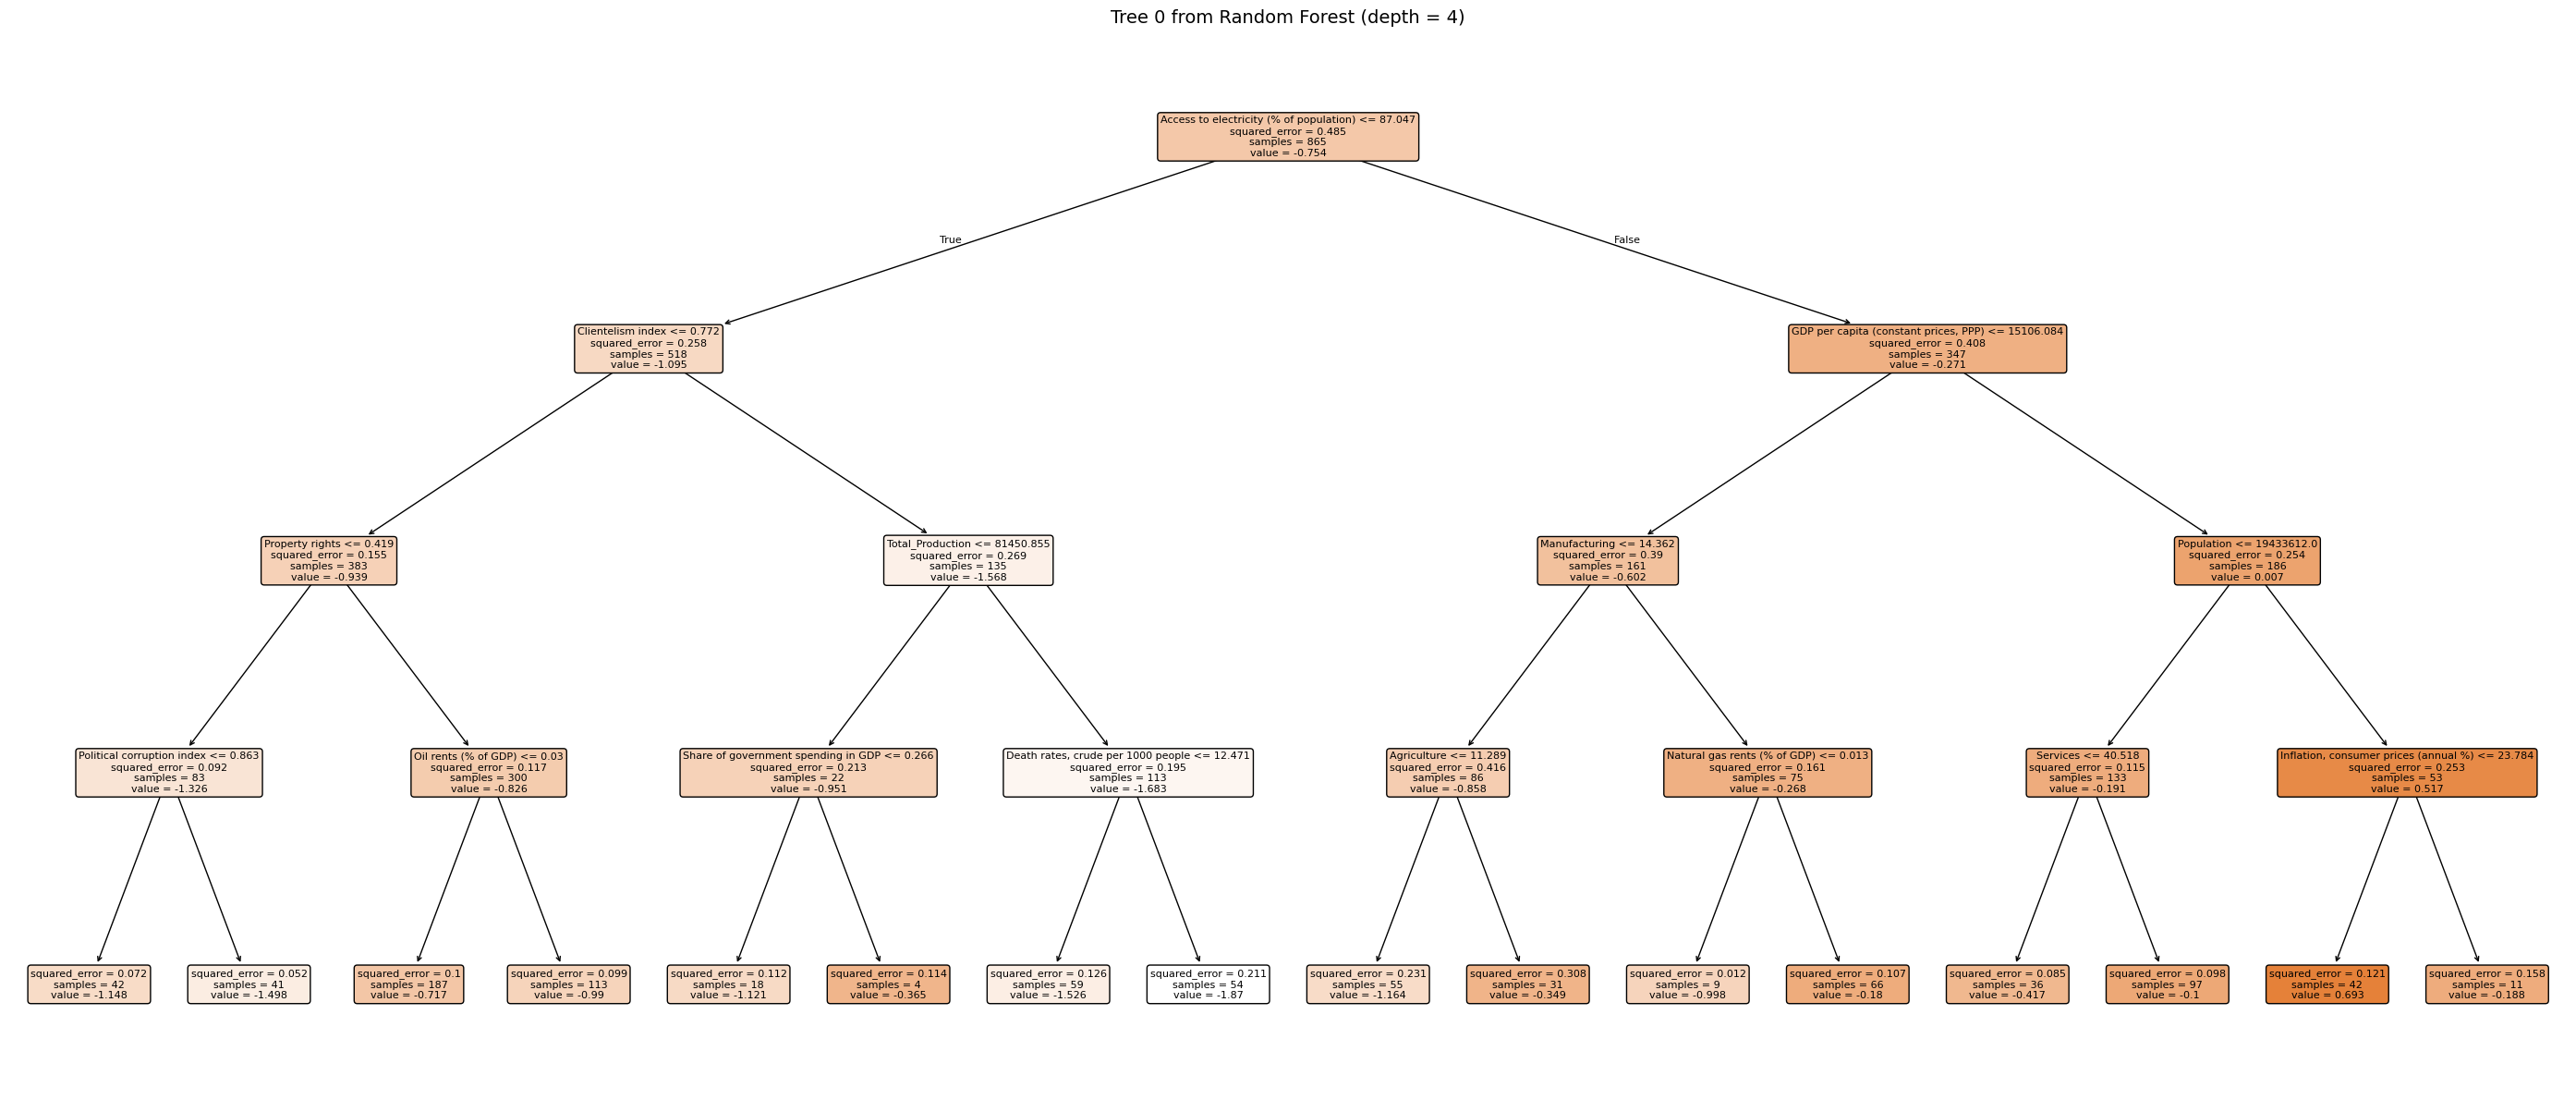

|--- Access to electricity (% of population) <= 87.05
|   |--- Clientelism index <= 0.77
|   |   |--- Property rights <= 0.42
|   |   |   |--- Political corruption index <= 0.86
|   |   |   |   |--- value: [-1.15]
|   |   |   |--- Political corruption index >  0.86
|   |   |   |   |--- value: [-1.50]
|   |   |--- Property rights >  0.42
|   |   |   |--- Oil rents (% of GDP) <= 0.03
|   |   |   |   |--- value: [-0.72]
|   |   |   |--- Oil rents (% of GDP) >  0.03
|   |   |   |   |--- value: [-0.99]
|   |--- Clientelism index >  0.77
|   |   |--- Total_Production <= 81450.86
|   |   |   |--- Share of government spending in GDP <= 0.27
|   |   |   |   |--- value: [-1.12]
|   |   |   |--- Share of government spending in GDP >  0.27
|   |   |   |   |--- value: [-0.37]
|   |   |--- Total_Production >  81450.86
|   |   |   |--- Death rates, crude per 1000 people <= 12.47
|   |   |   |   |--- value: [-1.53]
|   |   |   |--- Death rates, crude per 1000 people >  12.47
|   |   |   |   |--- value

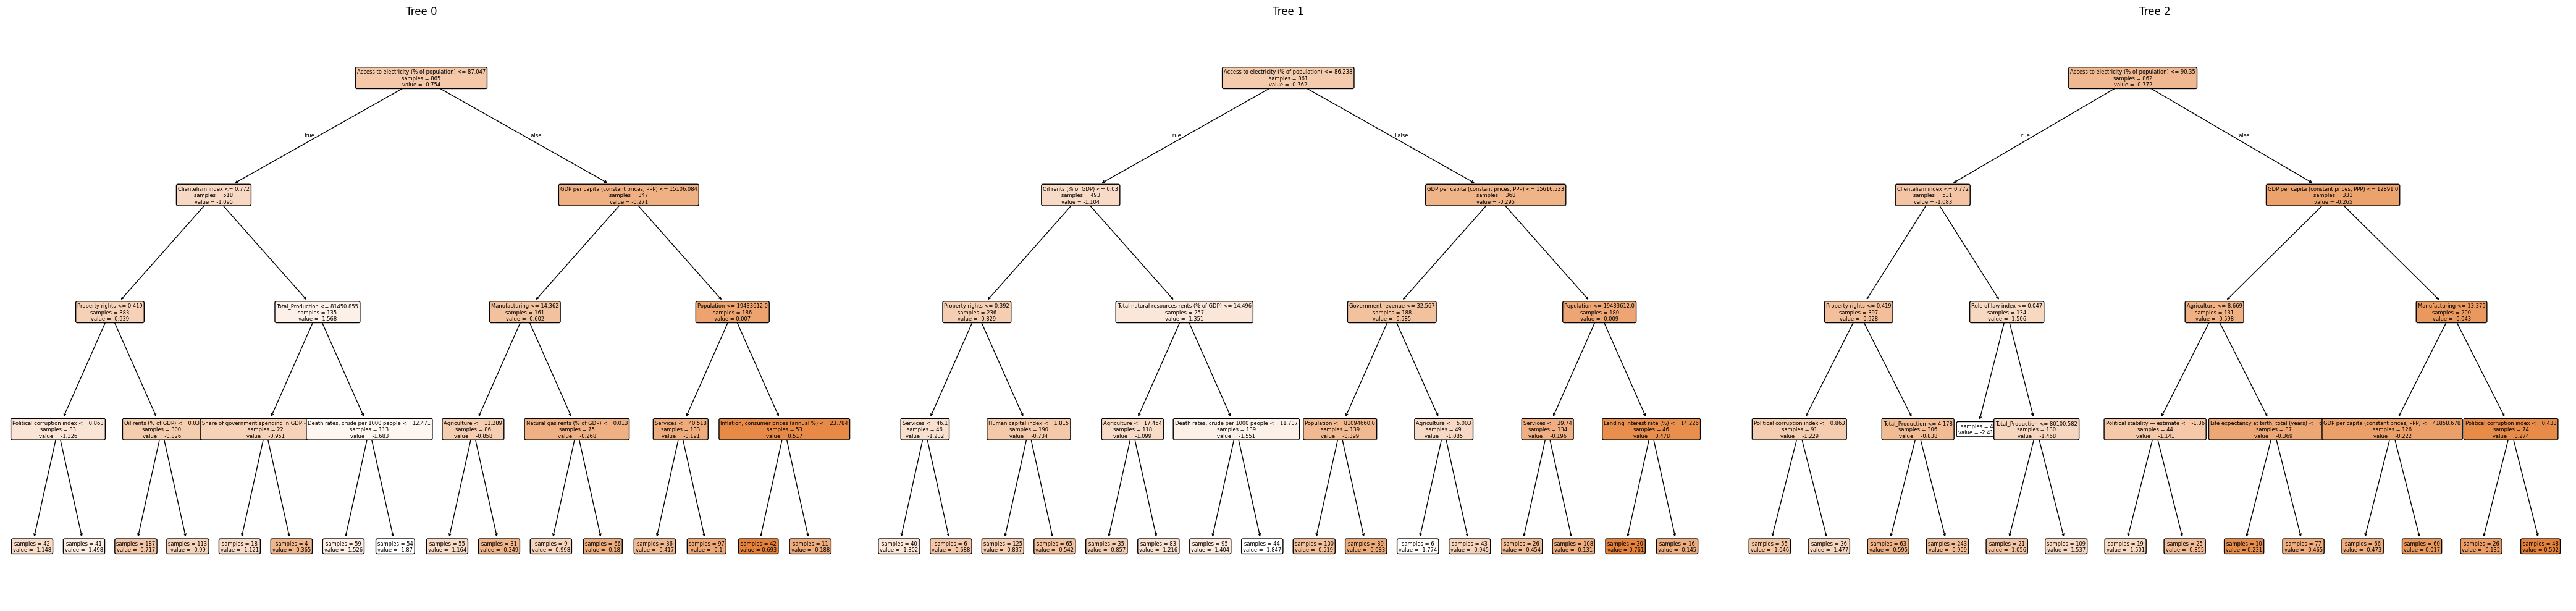

Most representative tree: index 175 (r = 0.9556)


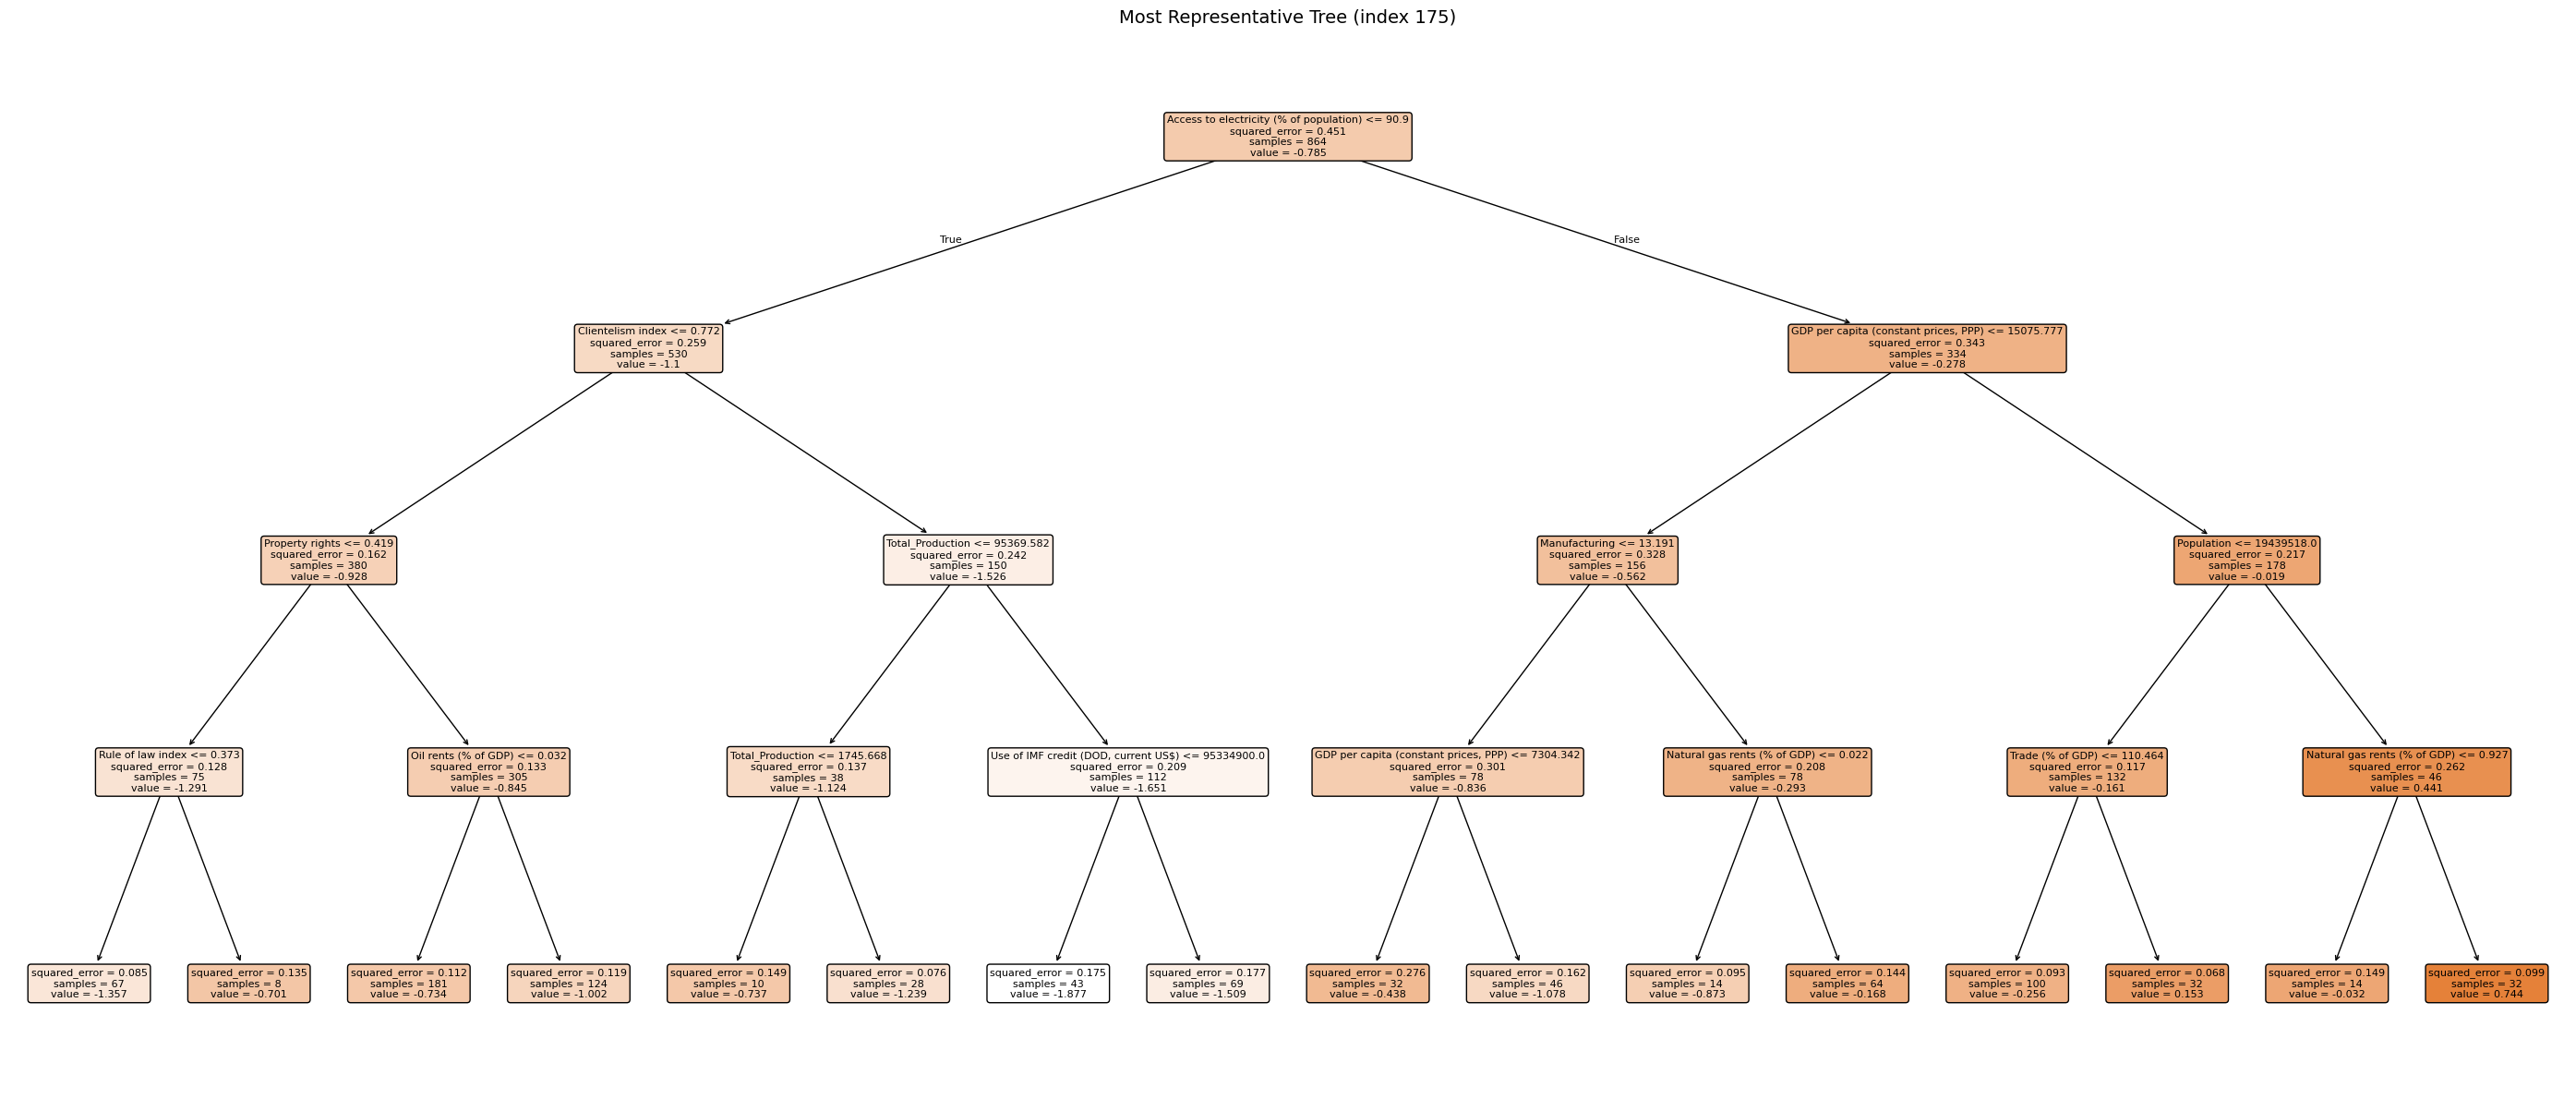

In [ ]:
# from sklearn.tree import plot_tree, export_text
# import matplotlib.pyplot as plt

# # ----------------------------
# # 1. Plot a single tree from the forest
# # ----------------------------
# fig, ax = plt.subplots(figsize=(28, 12))
# plot_tree(
#     rf.estimators_[0],          # first tree (change index to inspect others)
#     feature_names=feature_names,
#     filled=True,                # colour nodes by predicted value
#     rounded=True,
#     fontsize=8,
#     ax=ax,
#     impurity=True,              # show MSE at each node
#     proportion=False,
# )
# ax.set_title("Tree 0 from Random Forest (depth = 4)", fontsize=14)
# plt.tight_layout()
# plt.savefig(r'..\figures\rf_tree_0.png', dpi=200, bbox_inches='tight')
# plt.show()

# # ----------------------------
# # 2. Text representation (quick inspection)
# # ----------------------------
# tree_text = export_text(
#     rf.estimators_[0],
#     feature_names=list(feature_names),
#     max_depth=4
# )
# print(tree_text)

# # ----------------------------
# # 3. Compare a few trees side by side
# # ----------------------------
# fig, axes = plt.subplots(1, 3, figsize=(42, 10))
# for i, ax in enumerate(axes):
#     plot_tree(
#         rf.estimators_[i],
#         feature_names=feature_names,
#         filled=True,
#         rounded=True,
#         fontsize=6,
#         ax=ax,
#         impurity=False,
#     )
#     ax.set_title(f"Tree {i}", fontsize=12)

# plt.tight_layout()
# plt.savefig(r'..\figures\rf_trees_comparison.png', dpi=200, bbox_inches='tight')
# plt.show()

# # ----------------------------
# # 4. Most "representative" tree (closest to ensemble prediction)
# # ----------------------------
# # Each tree makes predictions — find the one whose predictions
# # are most correlated with the full forest's predictions
# from scipy.stats import pearsonr

# rf_pred = rf.predict(X_imputed)
# correlations = []
# for i, tree in enumerate(rf.estimators_):
#     tree_pred = tree.predict(X_imputed)
#     r, _ = pearsonr(tree_pred, rf_pred)
#     correlations.append(r)

# best_tree_idx = int(np.argmax(correlations))
# print(f"Most representative tree: index {best_tree_idx} (r = {correlations[best_tree_idx]:.4f})")

# fig, ax = plt.subplots(figsize=(28, 12))
# plot_tree(
#     rf.estimators_[best_tree_idx],
#     feature_names=feature_names,
#     filled=True,
#     rounded=True,
#     fontsize=8,
#     ax=ax,
# )
# ax.set_title(f"Most Representative Tree (index {best_tree_idx})", fontsize=14)
# plt.tight_layout()
# plt.savefig(r'..\figures\rf_best_tree.png', dpi=200, bbox_inches='tight')
# plt.show()

## 2) Only ECI lag

In [17]:
# ----------------------------
# 1. Drop rows with missing outcome
# ----------------------------
df_clean = master_data_lags_ECI.dropna(subset=['Economic Complexity Index']).copy()
df_clean = df_clean.dropna(axis=1, how='all')

# ----------------------------
# 2. Separate outcome and predictors
# ----------------------------
y = df_clean['Economic Complexity Index'].values

X = df_clean.drop(columns=['Country Code', 'Country Name', 'Economic Complexity Index', 'Year']).values
feature_names = df_clean.drop(columns=['Country Code', 'Country Name', 'Economic Complexity Index', 'Year']).columns

# ----------------------------
# 3. Impute missing predictor values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ----------------------------
# 4. Standardize predictors
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ----------------------------
# 5. LASSO with cross-validation
# ----------------------------
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients (indexed by feature names, not rows!)
# ----------------------------
coef = pd.Series(lasso_cv.coef_, index=feature_names)
#print("LASSO coefficients:\n", coef)

# ----------------------------
# 7. Selected predictors (non-zero coefficients)
# ----------------------------
selected = coef[coef != 0].sort_values(key=abs, ascending=False)
#print("Selected predictors:\n", selected)

######################################################
# ----------------------------
# 5. RIDGE with cross-validation
# ----------------------------
ridge_cv = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=10
)
ridge_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients
# ----------------------------
coef = pd.Series(ridge_cv.coef_, index=feature_names)

# ----------------------------
# 7. Rank predictors by importance
# ----------------------------
ranked = coef.abs().sort_values(ascending=False)

##########################################################
# ----------------------------
# 6. Random Forest (3 levels)
# ----------------------------
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=4,          # <-- 3 levels
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imputed, y)

# ----------------------------
# 7. Feature importance
# ----------------------------
importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Keep only top 10 variables
importance_top10 = importance.head(15)

# ----------------------------
# 8. LASSO Plot
# ----------------------------
selected_sorted = selected.sort_values()
df_plot = selected_sorted.reset_index()
df_plot.columns = ['Feature', 'Coefficient']

fig_lasso = px.bar(
    df_plot,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title="Selected predictors (LASSO), ECI lag"
    # no text argument → no numbers on bars
)

fig_lasso.update_layout(yaxis=dict(autorange="reversed"))  # invert y-axis
fig_lasso.write_html(r'..\figures\Lasso_ECI_lag.html')     # save interactive HTML
fig_lasso.show() 

# ----------------------------
# 8. RIDGE Plot
# ----------------------------
# Predictors 
top_k = 20

# Sort and select top predictors
top_predictors = coef.loc[ranked.index[:top_k]].sort_values()

df_plot = top_predictors.reset_index()
df_plot.columns = ['Feature', 'Coefficient']

fig_ridge = px.bar(
    df_plot,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title="Top predictors (Ridge), ECI lag"
)

fig_ridge.update_layout(yaxis=dict(autorange="reversed"))  # invert y-axis
fig_ridge.write_html(r'..\figures\Ridge_ECI_lag.html')      # save interactive HTML
fig_ridge.show()    
# ----------------------------
# 8. RF Plot
# ----------------------------

fig_rf = px.bar(
    importance_top10,
    orientation='h',
    title="Top 10 Feature Importance (Random Forest, depth = 4) ECI lag",
    labels={'value': 'Importance', 'index': 'Feature'}
)
fig_rf.update_layout(yaxis=dict(autorange="reversed"), showlegend=False)
fig_rf.write_html(r'..\figures\RF_ECI_lag.html')
fig_rf.show()



## 3) All lags

In [18]:
# ----------------------------
# 1. Drop rows with missing outcome
# ----------------------------
df_clean = master_data_lags.dropna(subset=['Economic Complexity Index']).copy()
df_clean = df_clean.dropna(axis=1, how='all')

# ----------------------------
# 2. Separate outcome and predictors
# ----------------------------
y = df_clean['Economic Complexity Index'].values

X = df_clean.drop(columns=['Country Code', 'Country Name', 'Economic Complexity Index', 'Year']).values
feature_names = df_clean.drop(columns=['Country Code', 'Country Name', 'Economic Complexity Index', 'Year']).columns

# ----------------------------
# 3. Impute missing predictor values
# ----------------------------
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

# ----------------------------
# 4. Standardize predictors
# ----------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

# ----------------------------
# 5. LASSO with cross-validation
# ----------------------------
lasso_cv = LassoCV(cv=10, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients (indexed by feature names, not rows!)
# ----------------------------
coef = pd.Series(lasso_cv.coef_, index=feature_names)
#print("LASSO coefficients:\n", coef)

# ----------------------------
# 7. Selected predictors (non-zero coefficients)
# ----------------------------
selected = coef[coef != 0].sort_values(key=abs, ascending=False)
#print("Selected predictors:\n", selected)

######################################################
# ----------------------------
# 5. RIDGE with cross-validation
# ----------------------------
ridge_cv = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=10
)
ridge_cv.fit(X_scaled, y)

# ----------------------------
# 6. Extract coefficients
# ----------------------------
coef = pd.Series(ridge_cv.coef_, index=feature_names)

# ----------------------------
# 7. Rank predictors by importance
# ----------------------------
ranked = coef.abs().sort_values(ascending=False)

##########################################################
# ----------------------------
# 6. Random Forest (3 levels)
# ----------------------------
rf = RandomForestRegressor(
    n_estimators=1000,
    max_depth=4,          # <-- 3 levels
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_imputed, y)

# ----------------------------
# 7. Feature importance
# ----------------------------
importance = pd.Series(
    rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False)

# Keep only top 10 variables
importance_top10 = importance.head(15)

# ----------------------------
# 8. LASSO Plot
# ----------------------------
selected_sorted = selected.sort_values()
df_plot = selected_sorted.reset_index()
df_plot.columns = ['Feature', 'Coefficient']

fig_lasso = px.bar(
    df_plot,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title="Selected predictors (LASSO), all lag"
    # no text argument → no numbers on bars
)

fig_lasso.update_layout(yaxis=dict(autorange="reversed"))  # invert y-axis
fig_lasso.write_html(r'..\figures\Lasso_all_lags.html')     # save interactive HTML
fig_lasso.show() 

# ----------------------------
# 8. RIDGE Plot
# ----------------------------
# Predictors 
top_k = 20

# Sort and select top predictors
top_predictors = coef.loc[ranked.index[:top_k]].sort_values()

df_plot = top_predictors.reset_index()
df_plot.columns = ['Feature', 'Coefficient']

fig_ridge = px.bar(
    df_plot,
    x='Coefficient',
    y='Feature',
    orientation='h',
    title="Top predictors (Ridge), all lags"
)

fig_ridge.update_layout(yaxis=dict(autorange="reversed"))  # invert y-axis
fig_ridge.write_html(r'..\figures\Ridge_all_lags.html')      # save interactive HTML
fig_ridge.show()    
# ----------------------------
# 8. RF Plot
# ----------------------------

fig_rf = px.bar(
    importance_top10,
    orientation='h',
    title="Top 10 Feature Importance (Random Forest, depth = 4) all lags",
    labels={'value': 'Importance', 'index': 'Feature'}
)
fig_rf.update_layout(yaxis=dict(autorange="reversed"), showlegend=False)
fig_rf.write_html(r'..\figures\RF_all_lags.html')
fig_rf.show()

